In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
import jax 
import jax.numpy as jnp

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer

In [6]:
def random_split_like_tree(rng_key, target=None, treedef=None):
    if treedef is None:
        treedef = jax.tree_structure(target)
    keys = jax.random.split(rng_key, treedef.num_leaves)
    return jax.tree_util.tree_unflatten(treedef, keys)


def tree_random_normal_like(rng_key, target):
    keys_tree = random_split_like_tree(rng_key, target)
    return jax.tree_util.tree_map(
        lambda l, k: jax.random.normal(k, l.shape, l.dtype),
        target,
        keys_tree,
    )

In [7]:
from typing import Callable


class FunctionalComponent:
    def __init__(self, id: int, function: Callable):
        self.id = id
        self.function = function

    def __call__(self, mask: ArrayLike,x: ArrayLike):
        def true_fn():
            return self.function(x)
        def false_fn():
            return x
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    
class NormalComponent:
    def __init__(self, id: int, shape: tuple):
        self.id = id
        self.shape = shape

    def __call__(self, mask: ArrayLike, rng, params):
        std = params[self.id]
        std = std.reshape(self.shape)
        def true_fn():
            return jax.random.normal(rng, self.shape) * jnp.exp(std)
        def false_fn():
            return jnp.zeros(self.shape)
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    
class GammaComponent:
    def __init__(self, id: int, shape: tuple):
        self.id = id
        self.shape = shape

    def __call__(self, mask: ArrayLike, rng, params):
        alpha = params[self.id]
        alpha = alpha.reshape(self.shape)
        def true_fn():
            return jax.random.gamma(rng, jnp.exp(alpha))
        def false_fn():
            return jnp.zeros(self.shape)
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
        

In [8]:
NUM_COMPONENTS = 6

random_source = NormalComponent(0, (1,))
sin_component = FunctionalComponent(1, jnp.sin)
cos_component = FunctionalComponent(2, jnp.cos)
random_noise = NormalComponent(3, (1,))
square_component = FunctionalComponent(4, lambda x: x**2)
sigmoid_component = FunctionalComponent(5, jax.nn.sigmoid)
gamma_component = GammaComponent(6, (1,))


NUM_SAMPLES = 500


PARAMS_STRUC = {0: jnp.array([0.]), 3: jnp.array([0.]), 6: jnp.array([0.])}

COMPONENT_PARAMETERIZES = [i in PARAMS_STRUC for i in range(NUM_COMPONENTS)]

def prior_params(rng):
    return tree_random_normal_like(rng, PARAMS_STRUC)

def f(component_mask, rng, params_model):
    rng1, rng2, rng3 = jax.random.split(rng, 3)
    x = random_source(component_mask, rng1, params_model)
    y = sin_component(component_mask, x)
    z = cos_component(component_mask, y)
    eps = random_noise(component_mask, rng2, params_model)
    out = z + eps
    out = square_component(component_mask, out)
    out_prob = sigmoid_component(component_mask, out)
    out_noise = out_prob + gamma_component(component_mask, rng3, params_model)
    return out_noise


2024-11-12 20:02:42.693413: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [ ]:
component_mask = jnp.array([True, False, True, True, False,True, True])  

params = prior_params(jax.random.PRNGKey(1))
rng = jax.random.PRNGKey(0)
keys = jax.random.split(rng, 1000)
outputs = jax.vmap(f, in_axes=(0, 0, None))(jnp.stack([component_mask]*1000), keys, params)

_ = plt.hist(outputs.flatten(), bins=100)

/tmp/ipykernel_2495/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)


KeyboardInterrupt: 

In [ ]:


def generate_data(rng_key, num_samples=NUM_SAMPLES):
    rng_key_model, rng_key_params, rng_data = jax.random.split(rng_key,3)
    component_mask = jax.random.bernoulli(rng_key_model, p=0.7, shape=(NUM_COMPONENTS,))
    keys = jax.random.split(rng_data, num_samples)
    params = prior_params(rng_key_params)
    outputs = jax.vmap(f, in_axes=[None,0,None])(component_mask, keys, params)


    return component_mask, outputs, params
    

In [ ]:
_, data, _ = generate_data(jax.random.PRNGKey(0))

/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)


In [ ]:
from typing import Any
from models import ModelIdentificationDecoder, Simformer, EDM, ScalarTokenizer, VectorTokenizer 
from probjax.nn import DeepSet, MLP

NUM_TRAINABLE = len(PARAMS_STRUC)
TRAINABLE_IDX = (0, 3, 6)

trial_net = MLP([1,50,100,200], rngs=nnx.Rngs(123))
summary_net = MLP([200,100,50], rngs=nnx.Rngs(124))
embedding_net = DeepSet(trial_net, summary_net)
model_decoder = ModelIdentificationDecoder(50, 50, num_layers=2, rngs=nnx.Rngs(0), context_net=embedding_net)
tokenizer = ScalarTokenizer(NUM_TRAINABLE, value_dim=20, id_dim=30, cond_dim=0, context_dim=50,rngs=nnx.Rngs(2))

param_decoder = EDM(Simformer(tokenizer, num_layers=2, rngs=nnx.Rngs(42)))

params1 = nnx.state(model_decoder, nnx.Param)
params2 = nnx.state(param_decoder, nnx.Param)
params = (params1, params2)

In [ ]:
model_decoder(component_mask,data)

Array([1.53, 1.53, 1.53, 1.53, 1.53, 1.53], dtype=float32)

In [ ]:
component_mask, data, model_params = generate_data(jax.random.PRNGKey(42))

/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)


(array([ 4., 20., 25., 23., 27., 27., 25., 23., 20., 20., 19., 11., 14.,
        16., 17., 20., 12., 14.,  9.,  9., 10.,  7., 11.,  5.,  5.,  9.,
         6.,  5.,  5.,  3.,  5.,  7.,  2.,  9.,  6.,  4.,  3.,  6.,  0.,
         3.,  1.,  2.,  4.,  2.,  1.,  1.,  2.,  1.,  1.,  2.,  2.,  0.,
         2.,  0.,  1.,  0.,  1.,  1.,  1.,  2.,  0.,  0.,  0.,  1.,  0.,
         0.,  1.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.616, 0.681, 0.746, 0.811, 0.877, 0.942, 1.007, 1.072, 1.138,
        1.203, 1.268, 1.333, 1.398, 1.464, 1.529, 1.594, 1.659, 1.725,
        1.79 , 1.855, 1.92 , 1.985, 2.051, 2.116, 2.181, 2.246, 2.312,
        2.377, 2.442, 2.507, 2.572, 2.638, 2.703, 2.768, 2.833, 2.899,
        2.964, 3.029, 3.094, 3.159, 3.225, 3.29 , 3.355, 3.42 , 3.486,
        3.551, 3.616, 3.681, 3.746, 3.812, 3.877, 3.942, 4.007, 4.073,
        

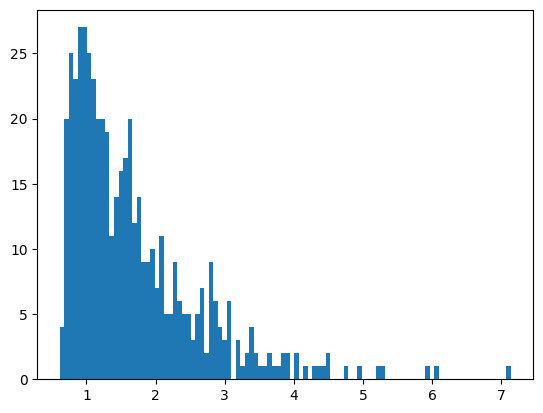

In [ ]:
plt.hist(data.flatten(), bins=100)

In [ ]:
logits, latents = model_decoder(component_mask, context=data, return_latents=True)

logits, latents.shape

(Array([1.53, 1.53, 1.53, 1.53, 1.53, 1.53], dtype=float32), (6, 50))

In [ ]:
model_params_flat = jnp.concatenate([model_params[i] for i in model_params]).reshape(1,3,1)
node_ids = jnp.arange(3).reshape(1,-1)
t = jnp.ones((1, 1,1))

In [ ]:
latents.shape

(6, 50)

In [ ]:
param_decoder(t, model_params_flat, node_ids, condition_mask=None, context = latents.sum(axis=-2))

Array([[[-1.145],
        [-0.049],
        [-0.71 ]]], dtype=float32)

In [ ]:
nnx.display(model_decoder)

In [ ]:
from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

def mean_fn(t, x):
    return x

def std_fn(t, x):
    return param_decoder.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(param_decoder, mean_fn=mean_fn, std_fn=std_fn, weight_fn=param_decoder.weight_fn, axis=-2)

In [ ]:
import optax


optimizer = optax.adam(5e-4)


train_num_samples = [10, 50, 100,NUM_SAMPLES, 2*NUM_SAMPLES]

def loss_fn(params, key):
    params1, params2 = params
    nnx.update(model_decoder, params1)
    l = 0.
    for n in train_num_samples:
        key, subkey = jax.random.split(key)
        key_data, key_dsm = jax.random.split(subkey)
        keys = jax.random.split(key_data, (100,))
        component_mask, data, params_model = jax.vmap(lambda k: generate_data(k, n))(keys)
        
        # Model identification loss
        logits_comp, latents = model_decoder(component_mask, context=data, return_latents=True)
        loss1 = jnp.mean(optax.sigmoid_binary_cross_entropy(logits_comp, component_mask))

        # Parameter prediction loss
        # Get trainable parameters
        model_params_flat = jnp.concatenate([params_model[i] for i in params_model], axis=-1).reshape(-1,NUM_TRAINABLE,1)
        latents_subset = latents[:, TRAINABLE_IDX, :]
        mask_subset = component_mask[:, TRAINABLE_IDX]

        attention_mask = mask_subset[:, :, None] & mask_subset[:, None, :]
        attention_mask = jnp.logical_or(attention_mask, jnp.eye(NUM_TRAINABLE, dtype=jnp.bool_))

        key_time, key_loss = jax.random.split(key_dsm)
        logt = jax.random.normal(key_time, shape=(100, 1,1)) * 1.2 - 1.2
        node_id = jnp.arange(NUM_TRAINABLE).reshape(1,-1).repeat(100, axis=0)
        t = jnp.exp(logt) + 0.0001
        loss2 = denoiser_loss_fn(params2, t, model_params_flat, node_id, condition_mask=None, context = latents_subset, attention_mask=attention_mask,rng=key_loss, loss_mask=~mask_subset.reshape(-1,NUM_TRAINABLE,1))



        # Weight loss for equal importance
        l+= loss2 + loss1
    return l / len(train_num_samples)


@jax.jit
def update(params, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [ ]:

key = jax.random.PRNGKey(0)
opt_state = optimizer.init(params)    

In [ ]:
loss_fn(params, key)

/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecat

Array(1.871, dtype=float32)

In [ ]:

for i in range(10_000):
    key, subkey, key2 = jax.random.split(key, 3)
    loss, params, opt_state = update(params,subkey, opt_state)
    if (i % 1000) == 0:
        print(loss)

/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecat

1.7275273
1.5526497
1.5315794
1.8301028
1.6571175
1.637349


KeyboardInterrupt: 

In [ ]:
nnx.update(model_decoder, params[0])
nnx.update(param_decoder, params[1])

In [ ]:
from probjax.utils.odeint import odeint


def naive_autoregressive_decoding(key, context, T=NUM_COMPONENTS):
    x = jnp.zeros((T,), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model_decoder(x.astype(jnp.int32), context)
        p_i = jax.nn.sigmoid(logits[i])
        
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[i].set(x_i)
        return (x, i+1), None
    keys = jax.random.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)
    
    return x[0]

def naive_diffusion_sampling(key,   latents):
    T_end = 10.
    rng_init, _ = jax.random.split(key)
    eps = jax.random.normal(rng_init, (NUM_TRAINABLE,)) * param_decoder.marginal_std(T_end)
    ts = jnp.linspace(0.001, T_end, 100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,NUM_TRAINABLE,1))
        f = param_decoder.drift(t,x_)
        g = param_decoder.diffusion(t, x_)
        score = param_decoder.score(t,x_, node_ids=jnp.arange(NUM_TRAINABLE)[None,], condition_mask=None, context=latents)
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")[-1]

In [ ]:
true_components, x_o, true_model_params = generate_data(jax.random.PRNGKey(12), 500)

/tmp/ipykernel_17316/1003478378.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)


In [ ]:
true_components

Array([False,  True,  True, False,  True,  True], dtype=bool)

In [ ]:
logits, latents = model_decoder(true_components, context=x_o, return_latents=True)
jax.nn.sigmoid(logits)

Array([0.146, 0.713, 0.993, 0.005, 0.785, 0.999], dtype=float32)

In [ ]:
component_samples = jax.vmap(lambda k: naive_autoregressive_decoding(k, x_o), in_axes=0)(jax.random.split(jax.random.PRNGKey(0), 100))

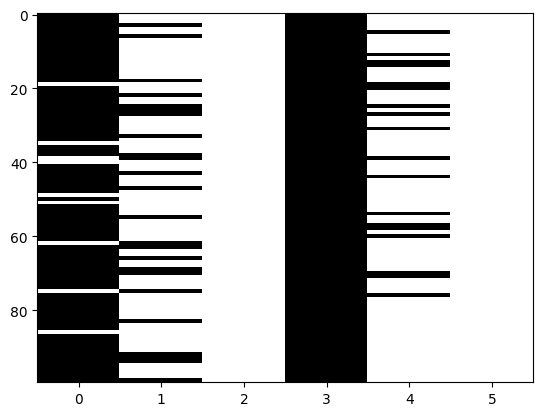

In [ ]:
plt.imshow(component_samples, aspect="auto", cmap="gray")

In [ ]:
idx = 0
component_mask = component_samples[idx]
component_mask

Array([False,  True,  True, False,  True,  True], dtype=bool)

In [ ]:
logits, latents = model_decoder(component_mask, context=x_o, return_latents=True)

In [ ]:
params_sampled = jax.vmap(lambda k: naive_diffusion_sampling(k, latents[None,TRAINABLE_IDX]))(jax.random.split(jax.random.PRNGKey(1), 1000))

(-4.0, 4.0)

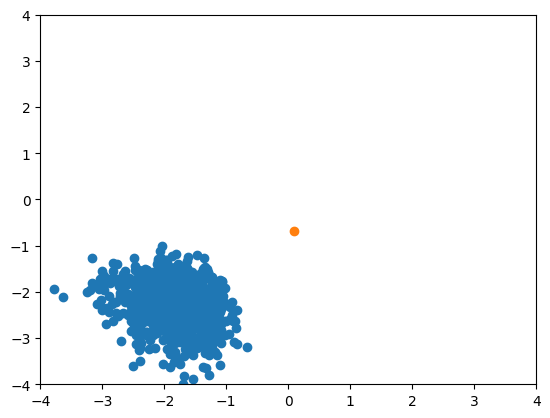

In [ ]:
plt.scatter(params_sampled[:,0], params_sampled[:,1])
plt.scatter(true_model_params[0], true_model_params[3])
plt.ylim(-4,4)
plt.xlim(-4,4)

In [ ]:
idx_param = 5
params_pred = {0: params_sampled[idx_param,0].flatten(), 3: params_sampled[idx_param,1].flatten(), 6: params_sampled[idx_param,2].flatten()}
x_pred = jax.vmap(lambda key : f(component_mask, key, params_pred))(jax.random.split(jax.random.PRNGKey(0), 1000))

In [ ]:
x_o.shape

(500, 1)

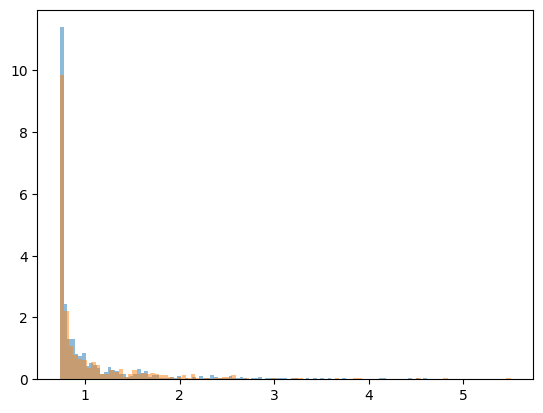

In [ ]:
_ = plt.hist(x_pred.flatten(), bins=100, alpha=0.5, density=True)
_ = plt.hist(x_o.flatten(), alpha=0.5, bins=100, density=True)